# Plot PCAs

This notebook generates PCA plots for every pooled (all-patient) profile
covered by `2.generate_pca.ipynb`.

**Inputs**
- PCA embeddings and per-component explained variance from `1.EDA/results/pca/`, produced by `2.generate_pca.ipynb`.
- `utils/r_plot_themes.r` for shared color palettes and plot themes.

**Outputs** (under `1.EDA/figures/pca/`)
- `2D_all_patients_pca.pdf`: one combined, multi-page PDF covering every 2D slice strategy (max projection, middle slice, middle N slice), entity (single cell, organoid), and profile variant (feature-selected, aggregate, consensus).
- `3D_all_patients_pca.pdf`: same, for every 3D normalization variant and profile variant.
- `3D_scfs_scree_plot.png`: a single scree plot (variance explained per component) across the 6 normalization variants of the 3D single-cell feature-selected profiles.

Each profile is plotted colored by treatment and by tumor type; feature-selected
profiles additionally get faceted-by-patient and faceted-by-tumor-type pages
(colored by treatment within each panel, matching the original per-panel
comparison this notebook was built for).

In [1]:
list_of_packages <- c("ggplot2", "dplyr", "tidyr", "circlize", "RColorBrewer")
for (package in list_of_packages) {
    suppressPackageStartupMessages(
        suppressWarnings(
            library(
                package,
                character.only = TRUE,
                quietly = TRUE,
                warn.conflicts = FALSE
            )
        )
    )
}

## Plotting helper

Shared functions used throughout:

- `plot_pca()` builds a single PC0 vs. PC1 scatterplot (colored or faceted).
- `save_plots_pdf()` bundles a list of plots into one multi-page PDF.

In [2]:
plot_pca <- function(data, explained_variance_df, title,
                      color_by, palette, legend_title = NULL,
                      facet_by = NULL, facet_nrow = 3,
                      alpha = 0.3, point_size = 0.5, background_alpha = 0.15,
                      width = 8, height = 8,
                      base_size = 8, rasterize_dpi = NULL) {
  # Build a single PC0 vs PC1 scatterplot in a consistent style.
  #
  # Faceting is a plain small-multiples split: facet_by only controls which
  # panel a point falls into, while color_by is independent and keeps its
  # own legend in every panel (unlike plot_umap()'s faceted mode, where
  # facet_by and color_by are the same variable and the legend is dropped).
  # Faceted panels additionally show the full point cloud dimmed grey as
  # context, matching plot_umap()'s background layer -- background_data has
  # the facet column removed so it repeats unchanged in every panel.
  #
  # Parameters
  # ----------
  # data : data.frame
  #     Data frame containing PC0, PC1, and the columns referenced by
  #     color_by and (optionally) facet_by.
  # explained_variance_df : data.frame
  #     Single-row data frame with PC0_explained_variance and
  #     PC1_explained_variance columns, used to label the axes.
  # title : str
  #     Plot title.
  # color_by : str
  #     Column name in `data` used to color points.
  # palette : named vector
  #     Colors keyed by the values of `color_by`, passed to scale_color_manual().
  # legend_title : str or None, optional
  #     Legend title for the color scale. If None, no title override is applied.
  # facet_by : str or None, optional
  #     Column name in `data` to facet by. If None, the plot is not faceted.
  # facet_nrow : int, optional
  #     Number of rows to use when faceting (ignored if facet_by is None).
  # alpha : float, optional
  #     Point transparency, in [0, 1]. In faceted mode, this applies to the
  #     highlighted (foreground) points only.
  # point_size : float, optional
  #     Point size.
  # background_alpha : float, optional
  #     Transparency of the grey context points in faceted mode (ignored if
  #     facet_by is None).
  # width, height : float, optional
  #     Plot dimensions in inches, used for the inline render size.
  # base_size : int, optional
  #     Base font size passed to theme_manuscript().
  # rasterize_dpi : int or None, optional
  #     If set, the point layer is rasterized (via ggrastr) at this
  #     resolution instead of staying vector. Keeps file size down for
  #     plots with many points, e.g. combined PDFs.
  #
  # Returns
  # -------
  # ggplot
  #     The plot object, returned visibly.
  options(repr.plot.width = width, repr.plot.height = height)

  var_pc0 <- explained_variance_df$PC0_explained_variance
  var_pc1 <- explained_variance_df$PC1_explained_variance
  x_label <- sprintf("PCA 1 (var explained %.0f%%)", var_pc0 * 100)
  y_label <- sprintf("PCA 2 (var explained %.0f%%)", var_pc1 * 100)

  point_layer <- function(...) {
    layer <- geom_point(...)
    if (!is.null(rasterize_dpi)) {
      layer <- ggrastr::rasterise(layer, dpi = rasterize_dpi)
    }
    layer
  }

  # Compact legend styling: smaller key swatches and tighter spacing so
  # many-row legends (e.g. 22 treatments) fit within the plot instead of
  # getting cut off, especially in the combined PDFs.
  compact_legend_theme <- theme(
    legend.key.size = unit(0.3, "cm"),
    legend.spacing.y = unit(0.05, "cm"),
    legend.text = element_text(size = base_size * 0.8),
    legend.title = element_text(size = base_size * 0.9)
  )

  guide_args <- list(override.aes = list(alpha = 1, size = 2), ncol = 1)
  if (!is.null(legend_title)) {
    guide_args$title <- legend_title
  }

  if (!is.null(facet_by)) {
    # Full point cloud, minus the facet column, so this layer repeats
    # unchanged in every panel instead of being split by facet.
    background_data <- data
    background_data[[facet_by]] <- NULL

    p <- ggplot(data, aes(x = PC0, y = PC1, color = .data[[color_by]])) +
      point_layer(data = background_data, color = "grey80", alpha = background_alpha, size = point_size) +
      point_layer(alpha = alpha, size = point_size) +
      scale_color_manual(values = palette) +
      labs(title = title, x = x_label, y = y_label) +
      theme_manuscript(base_size = base_size) +
      # PC0/PC1 carry different explained-variance scales, so coord_fixed()
      # (equal data-unit scaling) would often look badly non-square. Forcing
      # the panel aspect ratio to 1 instead keeps the rendered plot close to
      # square without distorting either axis's data range.
      theme(aspect.ratio = 1) +
      compact_legend_theme +
      guides(color = do.call(guide_legend, guide_args)) +
      facet_wrap(as.formula(paste0("~", facet_by)), nrow = facet_nrow)
  } else {
    p <- ggplot(data, aes(x = PC0, y = PC1, color = .data[[color_by]])) +
      point_layer(alpha = alpha, size = point_size) +
      scale_color_manual(values = palette) +
      labs(title = title, x = x_label, y = y_label) +
      theme_manuscript(base_size = base_size) +
      theme(aspect.ratio = 1) +
      compact_legend_theme +
      guides(color = do.call(guide_legend, guide_args))
  }

  p
}

In [3]:
save_plots_pdf <- function(plots, output_path, width = 8, height = 8) {
  # Save a list of ggplot objects as a single multi-page PDF, one page per
  # plot, in list order.
  #
  # Parameters
  # ----------
  # plots : list of ggplot
  #     Plots to save, one per page.
  # output_path : str
  #     File path for the combined PDF.
  # width, height : float, optional
  #     Page dimensions in inches.
  pdf(output_path, width = width, height = height)
  for (p in plots) {
    print(p)
  }
  dev.off()
}

In [4]:
# Get the current working directory and find Git root
find_git_root <- function() {
    # Get current working directory
    cwd <- getwd()
    
    # Check if current directory has .git
    if (dir.exists(file.path(cwd, ".git"))) {
        return(cwd)
    }
    
    # If not, search parent directories
    current_path <- cwd
    while (dirname(current_path) != current_path) {  # While not at root
        parent_path <- dirname(current_path)
        if (dir.exists(file.path(parent_path, ".git"))) {
            return(parent_path)
        }
        current_path <- parent_path
    }
    
    # If no Git root found, stop with error
    stop("No Git root directory found.")
}

# Find the Git root directory
root_dir <- find_git_root()
cat("Git root directory:", root_dir, "\n")
source(file.path(root_dir, "utils", "r_plot_themes.r"))

Git root directory: /Users/waygr/repos/wayscience/NF1_organoid_profile_analysis 


In [5]:
figures_path <- file.path(root_dir,"1.EDA/figures/pca")
if (!dir.exists(figures_path)) {
  dir.create(figures_path, recursive = TRUE)
}

## Tumor type classification

Same patient → tumor type mapping used in `1.plot_umap.ipynb` (cNF = cutaneous/subcutaneous
neurofibroma, pNF = plexiform neurofibroma, MPNST = malignant peripheral nerve
sheath tumor, Other = non-NF1-nerve-sheath diagnoses), applied to every PCA
plot below in addition to the treatment coloring already present.

In [6]:
# Tumor type classification (cNF = cutaneous/subcutaneous neurofibroma, pNF =
# plexiform neurofibroma, MPNST = malignant peripheral nerve sheath tumor).
# NF0030_T1 (myopericytoma), NF0040_T1 (schwannoma), and SARCO361_T1
# (sarcoma) are not NF1 nerve-sheath tumors and are grouped as "Other".
# Source: https://github.com/WayScience/NF1_3D_organoid_profiling_pipeline/blob/4072be16543851063df9bcd16500498f269f45fd/figures/table1_patients_and_counts/results/table1_patients_and_counts_results.tsv
tumor_type_lookup <- c(
  "NF0014_T1" = "cNF",
  "NF0014_T2" = "pNF",
  "NF0016_T1" = "pNF",
  "NF0018_T6" = "cNF",
  "NF0021_T1" = "cNF",
  "NF0030_T1" = "Other",
  "NF0035_T1" = "cNF",
  "NF0037_T1" = "cNF",
  "NF0040_T1" = "Other",
  "NF0055_T1" = "pNF",
  "SARCO219_T2" = "MPNST",
  "SARCO361_T1" = "Other"
)

tumor_type_palette <- c(
  "cNF" = "#1B9E77",
  "pNF" = "#D95F02",
  "MPNST" = "#7570B3",
  "Other" = "#999999"
)

## 2D PCA (max projection, middle slice, middle N slice)

In [7]:
pca_results_dir <- file.path(root_dir, "1.EDA/results/pca")

slice_specs <- list(
    list(dir_name = "max_projection", file_prefix = "2D_max_projection", title_label = "2D MIP"),
    list(dir_name = "middle_slice", file_prefix = "2D_middle_slice", title_label = "2D Middle Slice"),
    list(dir_name = "middle_n_slice", file_prefix = "2D_middle_n_slice", title_label = "2D Middle N Slice")
)

profile_specs_2d <- list(
    list(suffix = "fs_profiles", label = "FS", facet = TRUE),
    list(suffix = "agg_profiles", label = "Aggregate", facet = FALSE),
    list(suffix = "consensus_profiles", label = "Consensus", facet = FALSE)
)

entity_specs <- list(
    list(entity = "sc", entity_label = "Single Cell"),
    list(entity = "organoid", entity_label = "Organoid")
)

pca_plots_2D <- list()

for (slice in slice_specs) {
    for (entity in entity_specs) {
        for (profile in profile_specs_2d) {
            file_name <- paste0(slice$file_prefix, "_", entity$entity, "_", profile$suffix, "_embeddings.parquet")
            file_path <- file.path(pca_results_dir, file_name)
            explained_variance_file_name <- paste0(slice$file_prefix, "_", entity$entity, "_", profile$suffix, "_explained_variance.parquet")
            explained_variance_file_path <- file.path(pca_results_dir, explained_variance_file_name)

            if (!file.exists(file_path) || !file.exists(explained_variance_file_path)) {
                cat("Missing file, skipping:", file_path, "\n")
                next
            }

            df <- arrow::read_parquet(file_path)
            if (!"PC1" %in% colnames(df)) {
                cat("PC1 not found, skipping:", file_path, "\n")
                next
            }
            # Harmonize 2D column names to the 3D metadata convention, as
            # done in 1.plot_umap.ipynb
            df <- df %>%
                rename(
                    Metadata_Experiment_Treatment = Metadata_treatment,
                    Metadata_Biology_PatientTumor = Metadata_patient_tumor
                )
            df$Metadata_Biology_TumorType <- tumor_type_lookup[df$Metadata_Biology_PatientTumor]

            explained_variance_df <- arrow::read_parquet(explained_variance_file_path)
            title <- paste0("All patients: ", slice$title_label, " ", entity$entity_label, " ", profile$label, " Profiles")

            page_key <- paste0(slice$dir_name, "_", entity$entity, "_", profile$suffix)

            pca_plots_2D[[paste0(page_key, "_by_treatment")]] <- plot_pca(
                data = df, explained_variance_df = explained_variance_df, title = title,
                color_by = "Metadata_Experiment_Treatment", palette = custom_treatment_palette,
                legend_title = "Treatment", alpha = 0.3, rasterize_dpi = 150
            )
            pca_plots_2D[[paste0(page_key, "_by_tumor_type")]] <- plot_pca(
                data = df, explained_variance_df = explained_variance_df, title = title,
                color_by = "Metadata_Biology_TumorType", palette = tumor_type_palette,
                legend_title = "Tumor type", alpha = 0.18, rasterize_dpi = 150
            )

            if (profile$facet) {
                pca_plots_2D[[paste0(page_key, "_facet_by_patient")]] <- plot_pca(
                    data = df, explained_variance_df = explained_variance_df, title = title,
                    color_by = "Metadata_Experiment_Treatment", palette = custom_treatment_palette,
                    legend_title = "Treatment", facet_by = "Metadata_Biology_PatientTumor", facet_nrow = 3,
                    alpha = 0.5, point_size = 0.3, rasterize_dpi = 150
                )
                pca_plots_2D[[paste0(page_key, "_facet_by_tumor_type")]] <- plot_pca(
                    data = df, explained_variance_df = explained_variance_df, title = title,
                    color_by = "Metadata_Experiment_Treatment", palette = custom_treatment_palette,
                    legend_title = "Treatment", facet_by = "Metadata_Biology_TumorType", facet_nrow = 2,
                    alpha = 0.3, point_size = 0.15, rasterize_dpi = 150
                )
            }
        }
    }
}

save_plots_pdf(pca_plots_2D, file.path(figures_path, "2D_all_patients_pca.pdf"), width = 7, height = 7)

pdf 
  2

## 3D PCA (feature selected, aggregated, consensus profiles across all normalization variants)

In [8]:
# normalized profiles
normalized_profiles <- c(
    "organoid_norm",
    "sammed_organoid_norm",
    "sc_norm",
    "sammed_sc_norm",
    "nucleocentric_morphem_norm",
    "sammed_nucleocentric_norm"
)

profile_specs_3d <- list(
    list(file_prefix = "3D_1.feature_selected_profiles", suffix = "fs_profiles", label = "Feature Selected", facet = TRUE),
    list(file_prefix = "3D_2.aggregated_profiles", suffix = "sc_agg_profiles", label = "Aggregated", facet = FALSE),
    list(file_prefix = "3D_3.consensus_profiles", suffix = "sc_consensus_profiles", label = "Consensus", facet = FALSE)
)

pca_plots_3D <- list()

for (norm_profile in normalized_profiles) {
    for (profile in profile_specs_3d) {
        file_name <- paste0(profile$file_prefix, "_", norm_profile, "_", profile$suffix, "_embeddings.parquet")
        file_path <- file.path(pca_results_dir, file_name)
        explained_variance_file_name <- paste0(profile$file_prefix, "_", norm_profile, "_", profile$suffix, "_explained_variance.parquet")
        explained_variance_file_path <- file.path(pca_results_dir, explained_variance_file_name)

        if (!file.exists(file_path) || !file.exists(explained_variance_file_path)) {
            cat("Missing file, skipping:", file_path, "\n")
            next
        }

        df <- arrow::read_parquet(file_path)
        if (!"PC1" %in% colnames(df)) {
            cat("PC1 not found, skipping:", file_path, "\n")
            next
        }
        df$Metadata_Biology_TumorType <- tumor_type_lookup[df$Metadata_Biology_PatientTumor]

        explained_variance_df <- arrow::read_parquet(explained_variance_file_path)
        title <- paste0("All patients: 3D ", normalization_variant_labels[[norm_profile]], " ", profile$label, " Profiles")

        page_key <- paste0(norm_profile, "_", profile$suffix)

        pca_plots_3D[[paste0(page_key, "_by_treatment")]] <- plot_pca(
            data = df, explained_variance_df = explained_variance_df, title = title,
            color_by = "Metadata_Experiment_Treatment", palette = custom_treatment_palette,
            legend_title = "Treatment", alpha = 0.3, rasterize_dpi = 150
        )
        pca_plots_3D[[paste0(page_key, "_by_tumor_type")]] <- plot_pca(
            data = df, explained_variance_df = explained_variance_df, title = title,
            color_by = "Metadata_Biology_TumorType", palette = tumor_type_palette,
            legend_title = "Tumor type", alpha = 0.18, rasterize_dpi = 150
        )

        if (profile$facet) {
            pca_plots_3D[[paste0(page_key, "_facet_by_patient")]] <- plot_pca(
                data = df, explained_variance_df = explained_variance_df, title = title,
                color_by = "Metadata_Experiment_Treatment", palette = custom_treatment_palette,
                legend_title = "Treatment", facet_by = "Metadata_Biology_PatientTumor", facet_nrow = 3,
                alpha = 0.5, point_size = 0.3, rasterize_dpi = 150
            )
            pca_plots_3D[[paste0(page_key, "_facet_by_tumor_type")]] <- plot_pca(
                data = df, explained_variance_df = explained_variance_df, title = title,
                color_by = "Metadata_Experiment_Treatment", palette = custom_treatment_palette,
                legend_title = "Treatment", facet_by = "Metadata_Biology_TumorType", facet_nrow = 2,
                alpha = 0.3, point_size = 0.15, rasterize_dpi = 150
            )
        }
    }
}

save_plots_pdf(pca_plots_3D, file.path(figures_path, "3D_all_patients_pca.pdf"), width = 7, height = 7)

pdf 
  2

## Scree plot (3D single-cell feature-selected profiles)

Variance explained per component, across all 6 normalization variants of the
3D single-cell feature-selected profiles. Saved as a single PNG (not part of
the combined PDFs above).

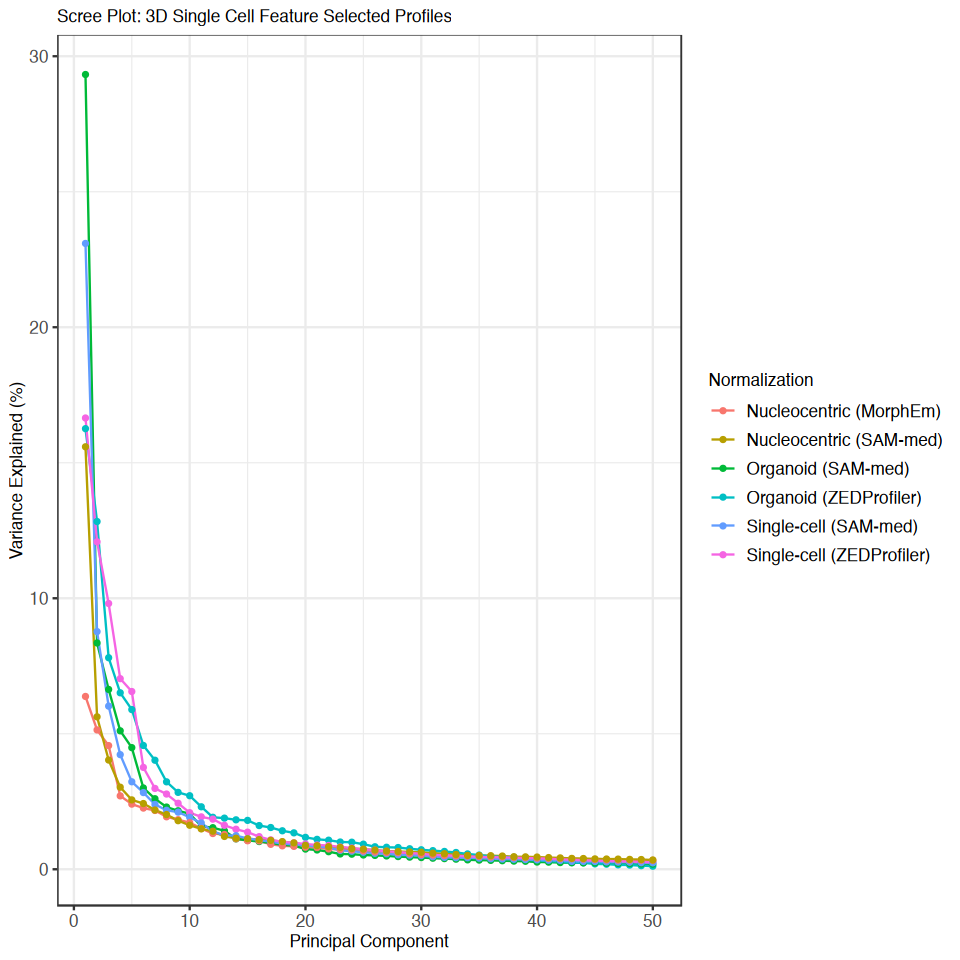

In [9]:
# Reuses normalized_profiles from the 3D PCA section above.
scree_df_list <- list()
for (norm_profile in normalized_profiles) {
    explained_variance_file_name <- paste0("3D_1.feature_selected_profiles_", norm_profile, "_fs_profiles_explained_variance.parquet")
    explained_variance_file_path <- file.path(pca_results_dir, explained_variance_file_name)

    if (!file.exists(explained_variance_file_path)) {
        cat("Missing file, skipping:", explained_variance_file_path, "\n")
        next
    }

    ev_df <- arrow::read_parquet(explained_variance_file_path)
    n_components <- ncol(ev_df)
    scree_df_list[[norm_profile]] <- data.frame(
        component = seq_len(n_components),
        variance_explained = as.numeric(ev_df[1, ]) * 100,
        norm_profile = normalization_variant_labels[[norm_profile]]
    )
}
scree_df <- do.call(rbind, scree_df_list)

scree_plot <- ggplot(scree_df, aes(x = component, y = variance_explained, color = norm_profile)) +
    geom_line() +
    geom_point(size = 1) +
    labs(
        title = "Scree Plot: 3D Single Cell Feature Selected Profiles",
        x = "Principal Component",
        y = "Variance Explained (%)",
        color = "Normalization"
    ) +
    theme_manuscript(base_size = 10)

ggsave(scree_plot, filename = file.path(figures_path, "3D_scfs_scree_plot.png"), width = 8, height = 6, dpi = 300)
scree_plot